loading... data
data head
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

C:\Users\birha\AppData\Local\Temp\ipykernel_22656\2764457847.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['MonthlyCharges'].median(), inplace=True)


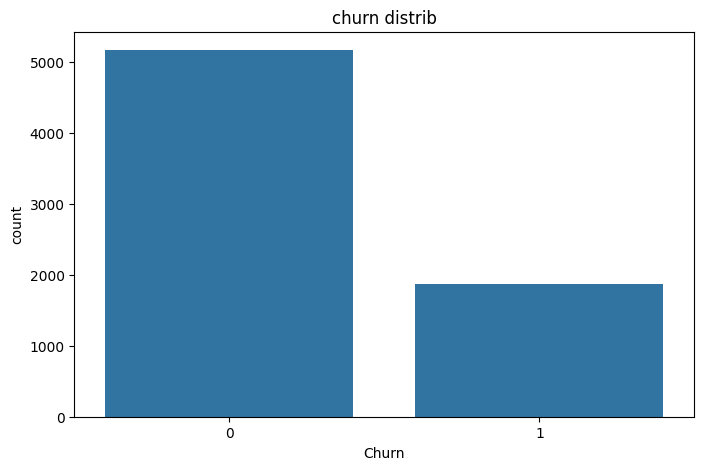

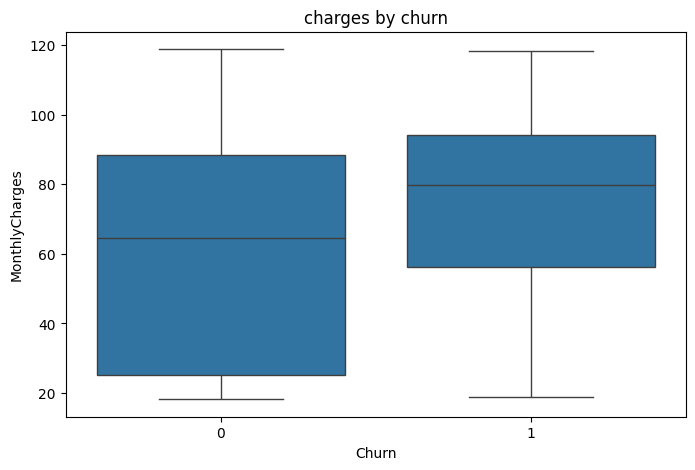

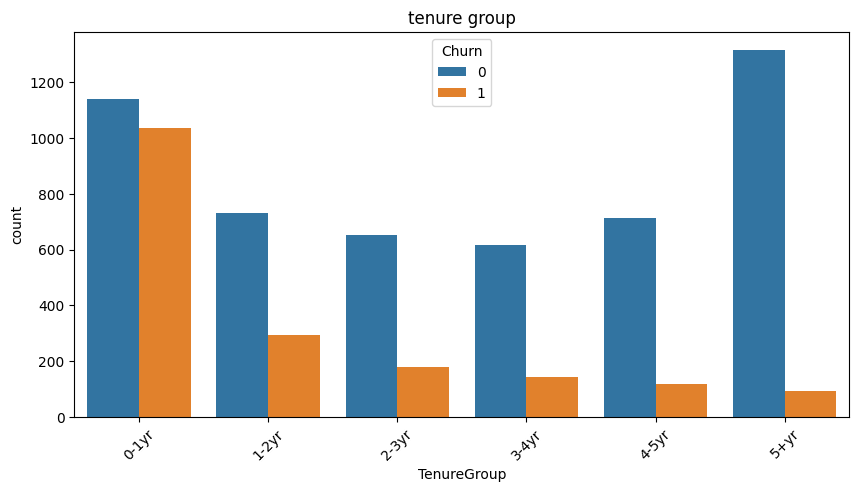

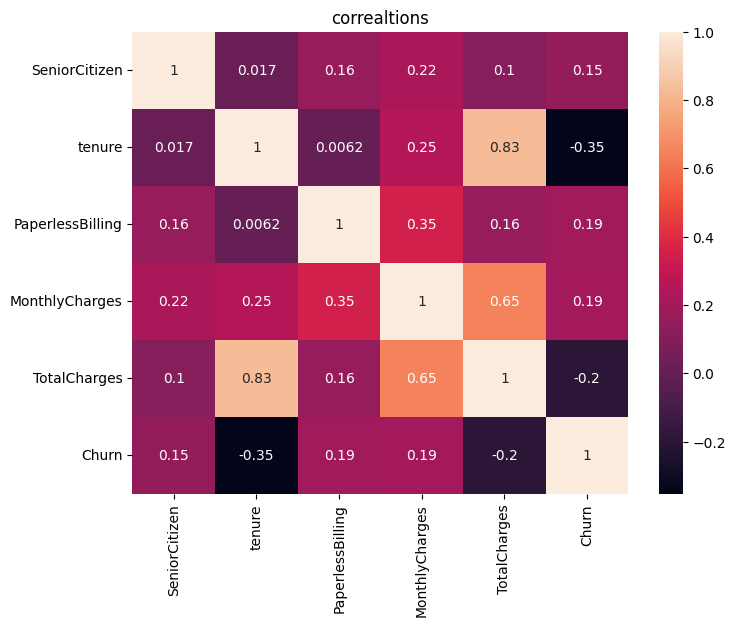

High pay churn: 0.35361428970136755
Low pay churn: 0.17398843930635838
making model
Logistic acc: 0.7721788502484032
RF acc: 0.7622427253371186
churn rate: 0.2653698707936959
best acc: 0.7622427253371186
saving file
done


In [5]:
#INST 414 Sprint 2: Customer Churn Prediction

# improt libs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# load the data
print("loading... data")
data = pd.read_csv('../data/raw/telco_churn.csv')
print("data head")
print(data.head())

# clean the data
print("cleaning..")
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['MonthlyCharges'].median(), inplace=True)
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})
data['PaperlessBilling'] = data['PaperlessBilling'].map({'Yes':1, 'No':0})
data['TenureGroup'] = pd.cut(data['tenure'],
bins=[0, 12, 24, 36, 48, 60, 72],
labels=['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr', '5+yr'])

# charts
plt.figure(figsize=(8,5))
sns.countplot(x='Churn', data=data)
plt.title("churn distrib")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title("charges by churn")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='TenureGroup', hue='Churn', data=data)
plt.title("tenure group")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("correaltions")
plt.show()

# Hypothesis
print("High pay churn:", data[data['MonthlyCharges'] > 70]['Churn'].mean())
print("Low pay churn:", data[data['MonthlyCharges'] <= 70]['Churn'].mean())

# make model
print("making model")
features = ['MonthlyCharges', 'tenure', 'TotalCharges', 'PaperlessBilling']
X = pd.get_dummies(data[features])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#logistic
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
log_pred = logreg.predict(X_test)
print("Logistic acc:", accuracy_score(y_test, log_pred))

#rf
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF acc:", accuracy_score(y_test, rf_pred))

# result
print("churn rate:", data['Churn'].mean())
print("best acc:", accuracy_score(y_test, rf_pred))

#save
import os
os.makedirs('data/processed', exist_ok=True)
print("saving file")
data.to_csv('data/processed/churn_analysis_results.csv', index=False)
print("done")
